In [1]:
import numpy as np
 
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))
 
print(sigmoid(0))            # 0.5  — exactly, by symmetry
print(sigmoid(100))          # ~1.0
print(sigmoid(-100))         # ~0.0
print(sigmoid(np.array([-1., 0., 1.])))   # works on whole arrays at once


0.5
1.0
3.7200759760208356e-44
[0.26894142 0.5        0.73105858]


In [2]:
import pandas as pd
df = pd.read_csv('C:\\Users\\susantraudt\\Compstats\\diabetes.csv')
df = df[(df['Glucose'] > 0) & (df['BMI'] > 0)]          # drop coded missingness
X = df[['Glucose', 'BMI']].to_numpy(dtype=float)
y = df['Outcome'].to_numpy(dtype=float)
 
X = (X - X.mean(axis=0)) / X.std(axis=0)                 # standardize
X = np.column_stack([X, np.ones(len(X))])                # intercept column
print(X.shape, y.shape)                                  # (752, 3) (752,)


(752, 3) (752,)


In [3]:
def predict(X, w):
    return sigmoid(X @ w)                # @ is matrix multiply
 
def loss(X, y, w):
    p = predict(X, w)
    eps = 1e-12                          # keeps log() away from exactly 0
    return -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
 
w = np.zeros(3)
print(loss(X, y, w))                     # 0.6931... = ln(2), the know-nothing loss


0.6931471805579452


0.6833223439586338 0.49103298469997914
[ 1.165  0.587 -0.802]


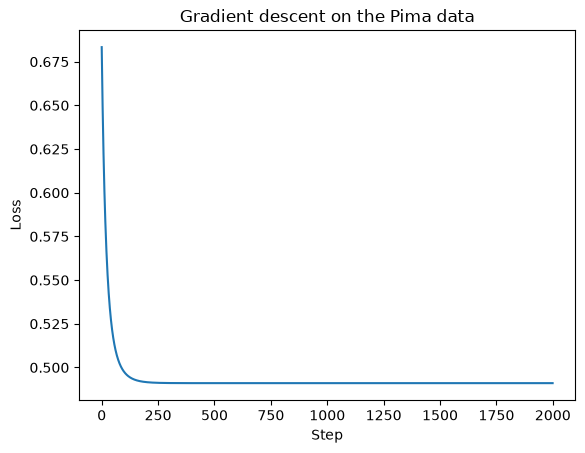

In [4]:
def gradient(X, y, w):
    return X.T @ (predict(X, w) - y) / len(y)
 
w = np.zeros(3)
lr = 0.1
losses = []
for step in range(2000):
    w = w - lr * gradient(X, y, w)       # THE line: walk downhill
    losses.append(loss(X, y, w))
 
print(losses[0], losses[-1])             # ~0.69 falling to ~0.47
print(w.round(3))                        # glucose weight ≈ 1.1, BMI ≈ 0.55, intercept ≈ -0.85
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel('Step'); plt.ylabel('Loss')
plt.title('Gradient descent on the Pima data'); plt.show()



In [5]:
from scipy.optimize import minimize
result = minimize(lambda w: loss(X, y, w), np.zeros(3), method='BFGS')
print(result.x.round(3))                 # matches your w to ~3 decimals


[ 1.165  0.587 -0.802]
